In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_theme(style = "whitegrid")

In [3]:
df = pd.read_csv("../data/train.csv")
print(f"Dataset shape: {df.shape[0]} rows , {df.shape[1]} columns")
df.head(10)

Dataset shape: 891 rows , 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# Describe Numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
#Describe Categorical columns
df.describe(include = 'object')

C:\Users\Mridul\AppData\Local\Temp\ipykernel_10232\4058464433.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = 'object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [7]:
#Missing value clunt
missing_value_count = df.isnull().sum()
print(missing_value_count)

#Percentage of missing value as whole dataset
total_cells = np.prod(df.shape)
total_missing = missing_value_count.sum()

missing_percentage = (total_missing/total_cells)*100
print(f"Missing Values Percentage : {missing_percentage}")

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing Values Percentage : 8.099513655069211


In [8]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing Percentage", ascending = False)
print("Columns with missing values: ")
missing

Columns with missing values: 


,Missing Count,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


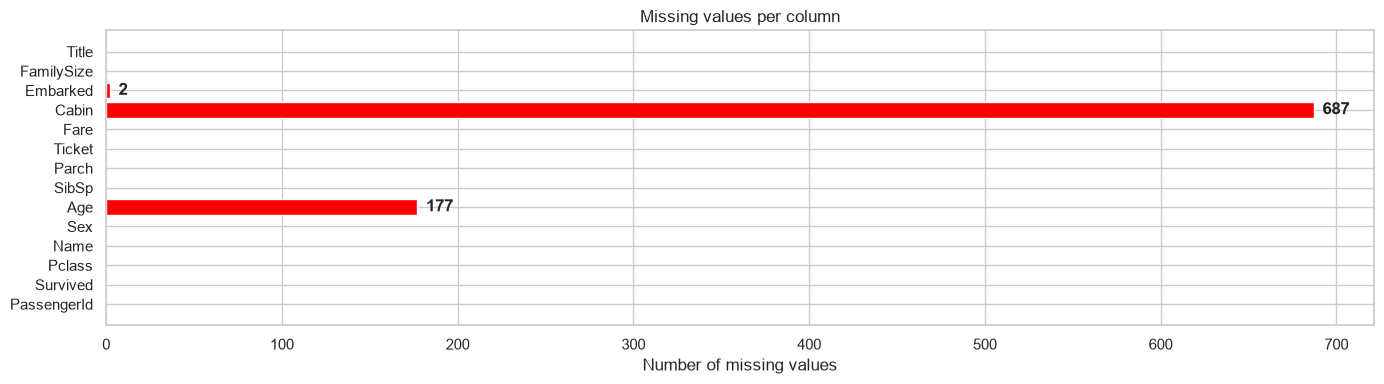

In [19]:
#Visulizing missing values
fig, ax = plt.subplots(figsize=(14,4))
colors = ["red" if df[col].isnull().sum().any() else "gray" for col in df.columns]
ax.barh(df.columns, df.isnull().sum(), color = colors)
ax.set_xlabel("Number of missing values")
ax.set_title("Missing values per column")
for i, v in enumerate(df.isnull().sum()):
    if v>0:
        ax.text(
            v+5,
            i,
            str(v),
            va="center",
            fontweight="bold"
        )
plt.tight_layout()
plt.show()

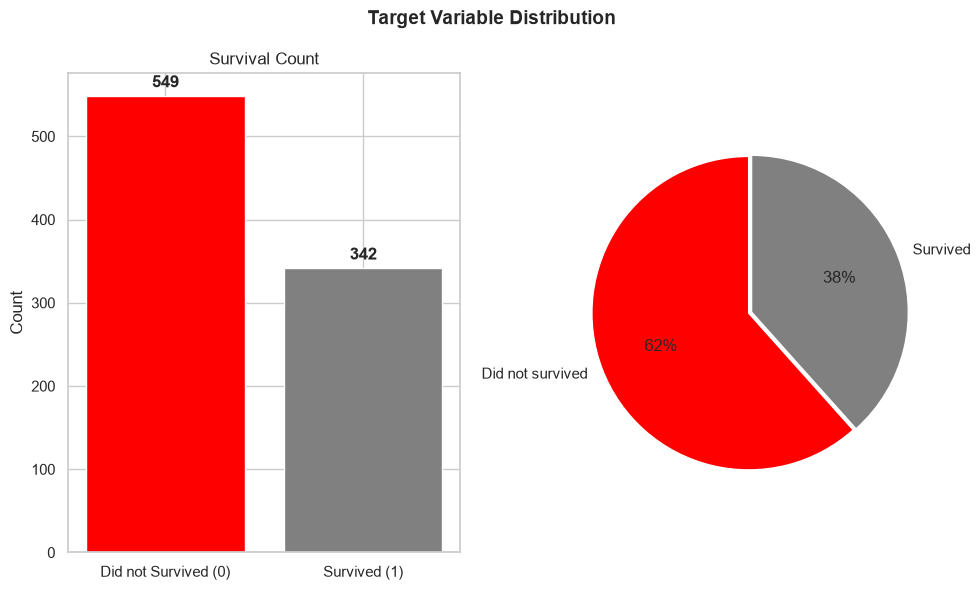


Survival Rate: 38.38%
Death Rate: 61.62%


In [10]:
# Target Variable Analysis
fig, ax = plt.subplots(figsize=(10,6))

survived_counts = df['Survived'].value_counts()
ax[0].bar(["Did not Survived (0)", "Survived (1)"], survived_counts.values , color=["red", "gray"])
ax[0].set_title("Survival Count")
ax[0].set_ylabel("Count")

for i, v in enumerate(survived_counts.values):
    ax[0].text(
        i,
        v + 10,
        str(v),
        ha="center",
        fontweight="bold"
    )

print(f"\nSurvival Rate: {df['Survived'].mean():.2%}")
print(f"Death Rate: {1 - df['Survived'].mean():.2%}")

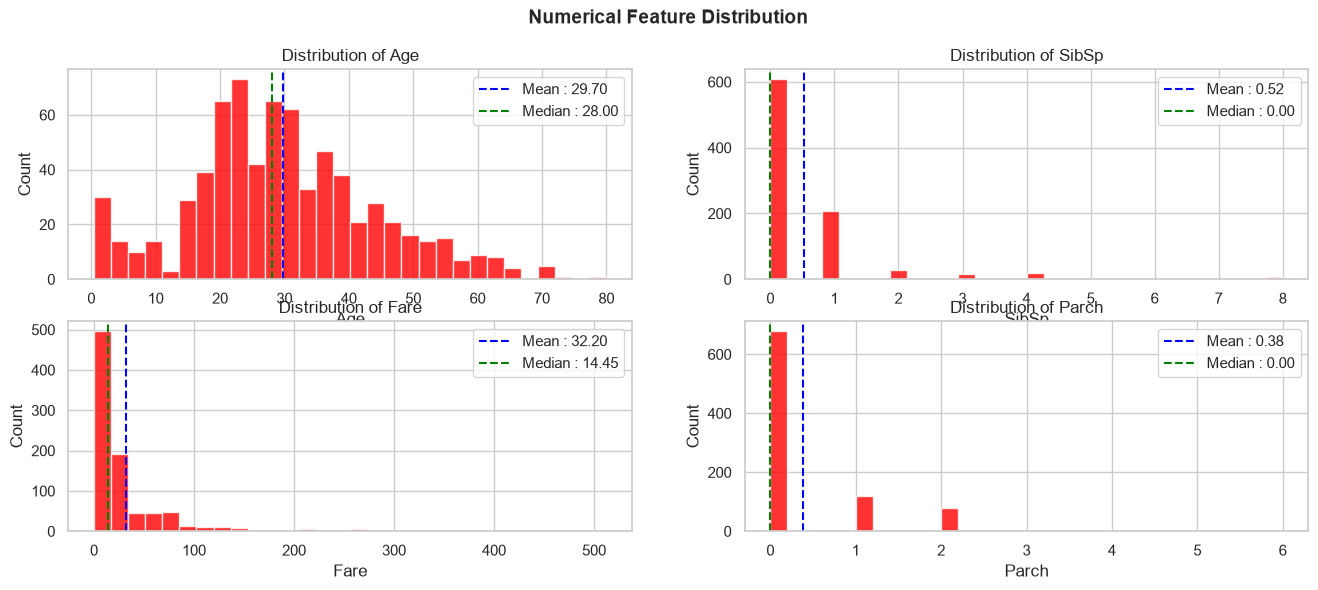

In [11]:
#Univariate Analysis
numerical_cols = ["Age", "SibSp", "Fare","Parch"]
fig, ax = plt.subplots(2,2, figsize=(16,6))
ax = ax.flatten()

for i, col in enumerate(numerical_cols):
    ax[i].hist(df[col].dropna(), bins = 30, color = "red", edgecolor = "white", alpha = 0.8)
    ax[i].axvline(df[col].mean(), color = "blue", linestyle="--", label = f"Mean : {df[col].mean():.2f}")
    ax[i].axvline(df[col].median(), color = "green", linestyle="--", label = f"Median : {df[col].median():.2f}")
    ax[i].set_title(f"Distribution of {col}")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Count")
    ax[i].legend()

fig.suptitle("Numerical Feature Distribution", fontsize = 14, fontweight = "bold")
plt.tight_layout
plt.show()

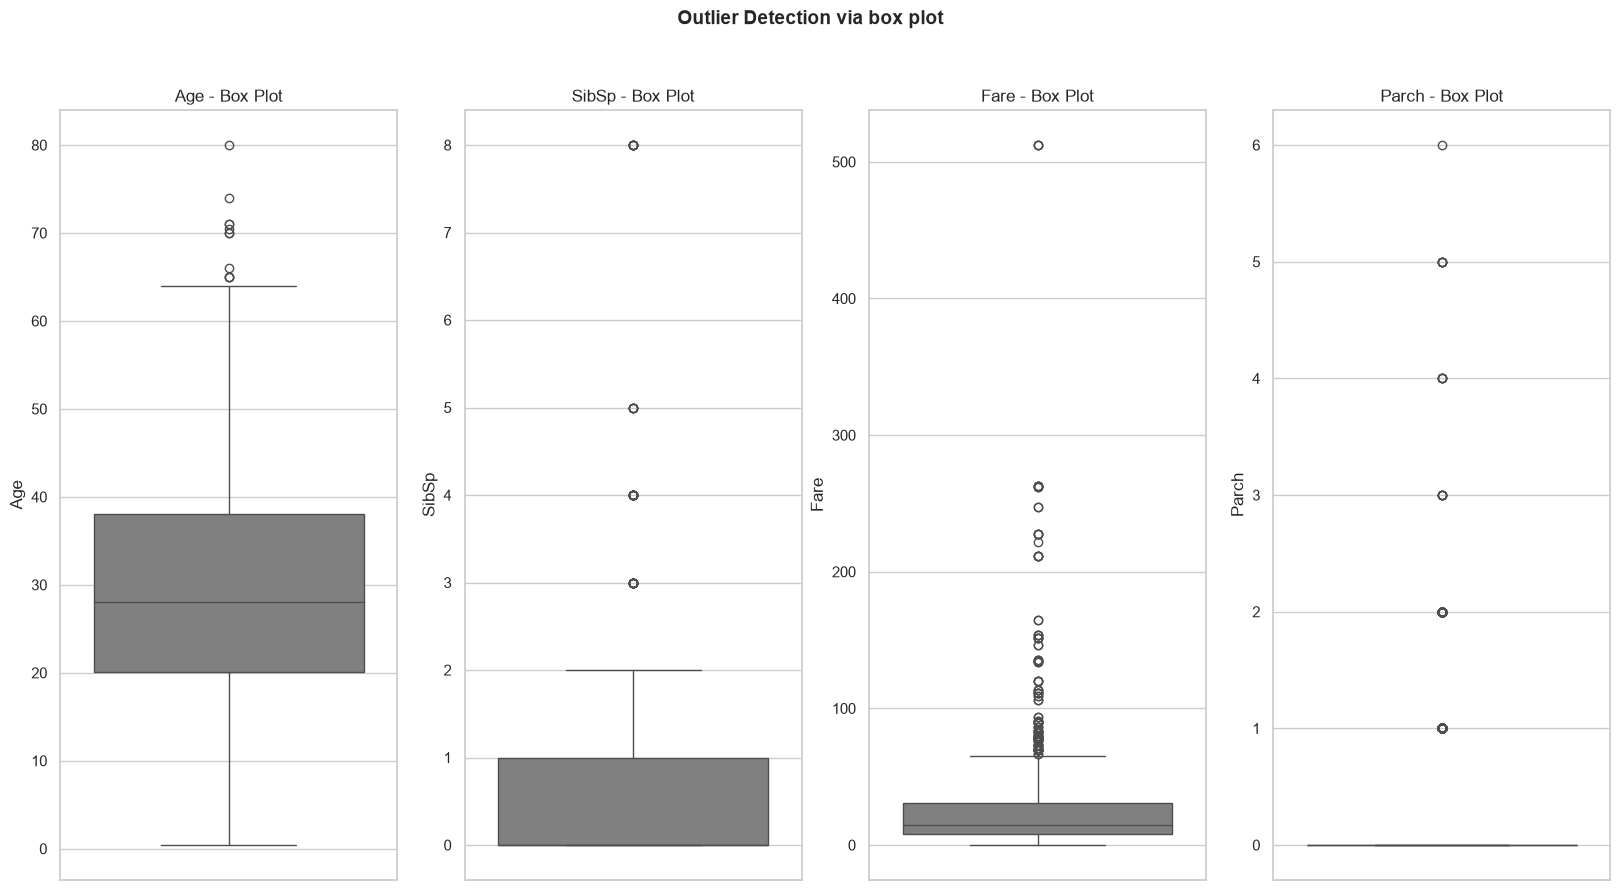

In [12]:
#box plots
fig, ax = plt.subplots(1, 4, figsize=(20,10))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax= ax[i], color = "gray")
    ax[i].set_title(f"{col} - Box Plot")
fig.suptitle("Outlier Detection via box plot", fontsize = 14, fontweight = "bold")
plt.tight_layout
plt.show()

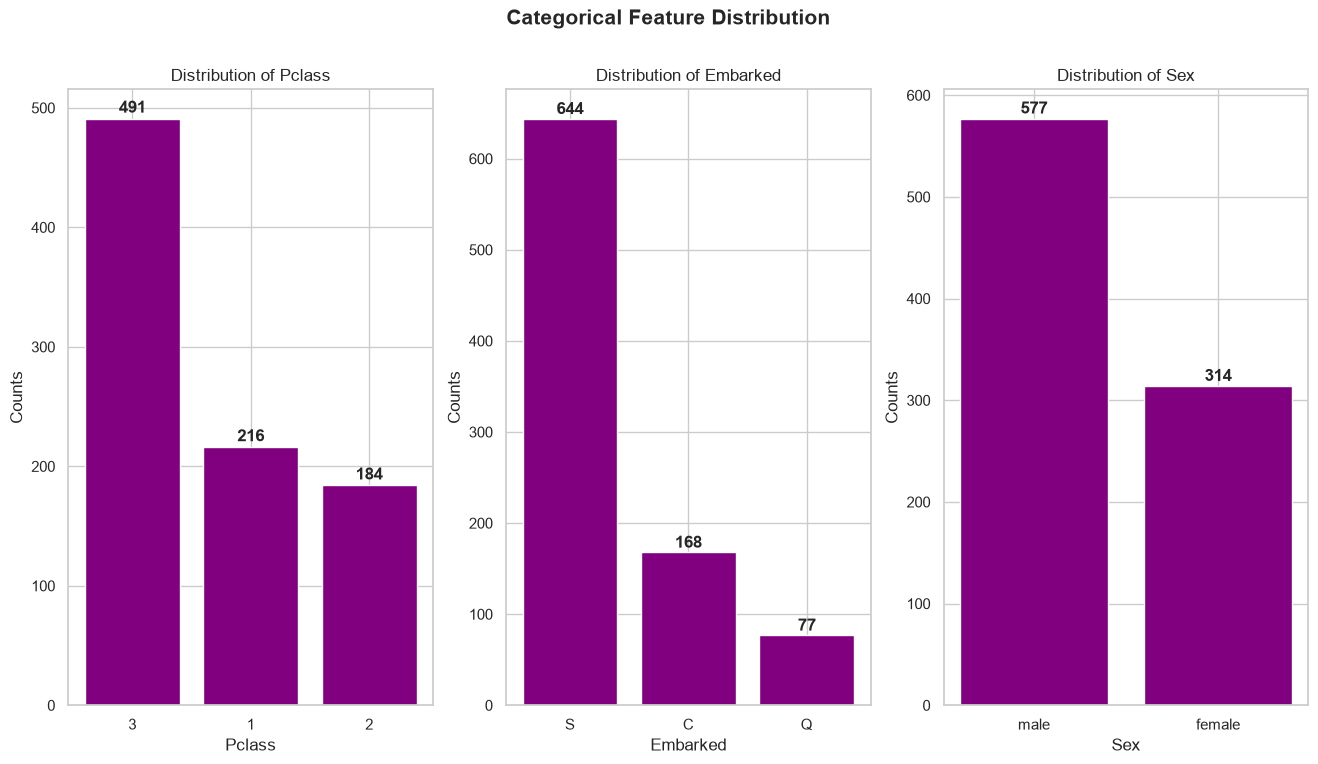

In [13]:
#Categorical Analysis
categorical_cols = ["Pclass", "Embarked", "Sex"]
fig, ax = plt.subplots(1, 3, figsize = (16,8))

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    ax[i].bar(counts.index.astype(str), counts.values, color = "purple", edgecolor = "white")
    ax[i].set_title(f"Distribution of {col}")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Counts")
    for j, v in enumerate(counts.values):
        ax[i].text(
            j, 
            v+5,
            str(v),
            ha="center",
            fontweight="bold"
        )
fig.suptitle("Categorical Feature Distribution", fontsize=15, fontweight="bold")
plt.tight_layout
plt.show()

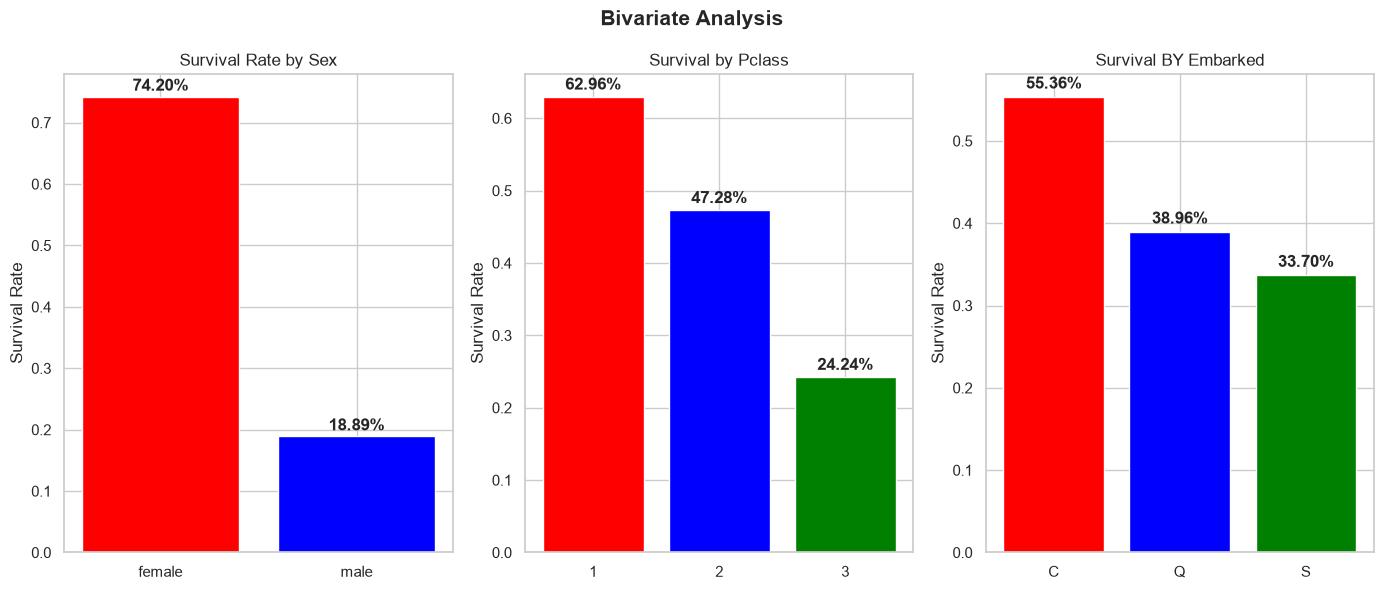

In [20]:
#Bivariate Analysis
fig, ax = plt.subplots(1, 3, figsize=(14,6))

survival_by_sex = df.groupby("Sex")["Survived"].mean()
ax[0].bar(survival_by_sex.index, survival_by_sex.values, color = ["red", "blue"])
ax[0].set_title("Survival Rate by Sex")
ax[0].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_sex.values):
    ax[0].text(
        i,
        v + 0.01,
        f"{v:.2%}",
        ha="center",
        fontweight="bold"
    )

survival_by_Pclass = df.groupby("Pclass")["Survived"].mean()
ax[1].bar(survival_by_Pclass.index.astype(str), survival_by_Pclass.values, color= ["red", "blue","green"])
ax[1].set_title("Survival by Pclass")
ax[1].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_Pclass.values):
    ax[1].text(
        i,
        v+0.01,
        f"{v:.2%}",
        ha="center",
        fontweight="bold"
    )

survival_by_Embarked = df.groupby("Embarked")["Survived"].mean()
ax[2].bar(survival_by_Embarked.index, survival_by_Embarked.values, color=["red","blue","green"])
ax[2].set_title("Survival BY Embarked")
ax[2].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_Embarked.values):
    ax[2].text(
        i,
        v+0.01,
        f"{v:.2%}",
        ha="center",
        fontweight="bold"
    )
    
fig.suptitle("Bivariate Analysis", fontsize= 15, fontweight="bold")
plt.tight_layout()
plt.show()

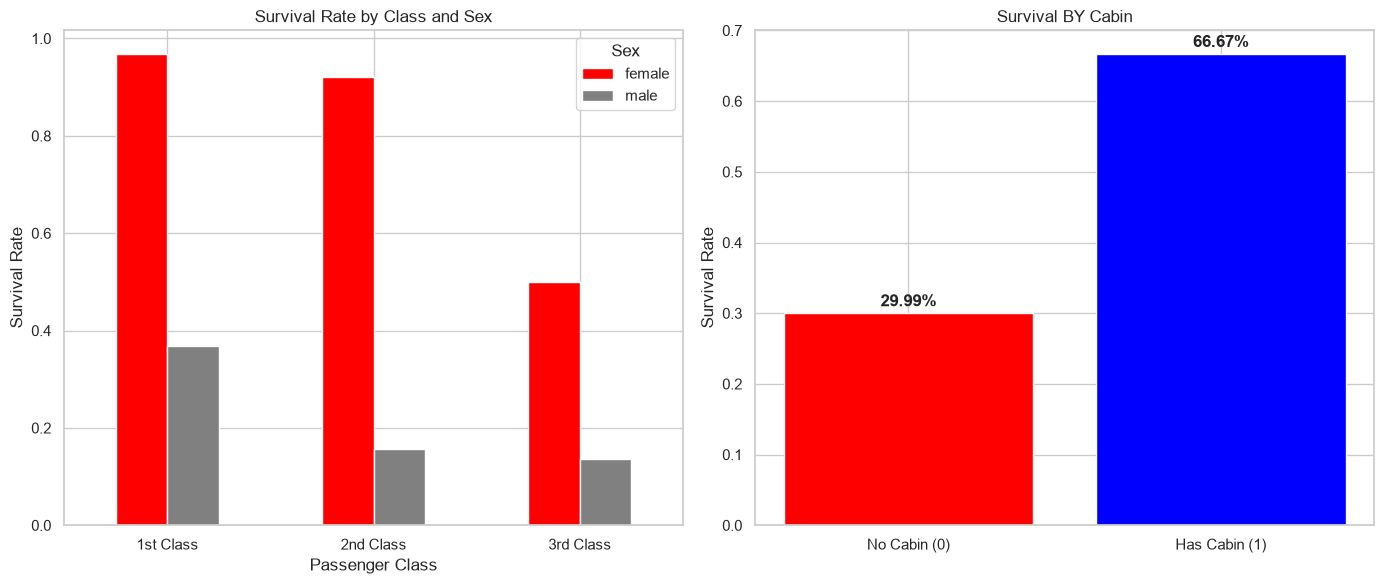

In [12]:
#Survival Rate by Sex and Pclass combined
fig, ax = plt.subplots(1,2, figsize=(14,6))

survival_grouped = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
survival_grouped.plot(kind="bar",ax=ax[0], color=["red", "gray"])
ax[0].set_title("Survival Rate by Class and Sex")
ax[0].set_ylabel("Survival Rate")
ax[0].set_xlabel("Passenger Class")
ax[0].set_xticklabels(["1st Class", "2nd Class", "3rd Class"], rotation=0)
ax[0].legend(title="Sex")

#Survival by hascabin

def has_cabin(x):
    if pd.isna(x):
        return 0
    else:
        return 1
df["HasCabin"] = df["Cabin"].apply(has_cabin)
def get_deck(x):
    if pd.isna(x):
        return "U"
    else:
        return x[0]
df["Deck"] = df["Cabin"].apply(get_deck)

survival_by_cabin = df.groupby("HasCabin")["Survived"].mean()
ax[1].bar(["No Cabin (0)", "Has Cabin (1)"], survival_by_cabin.values, color=["red","blue"])
ax[1].set_title("Survival BY Cabin")
ax[1].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_cabin.values):
    ax[1].text(
        i,
        v+0.01,
        f"{v:.2%}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

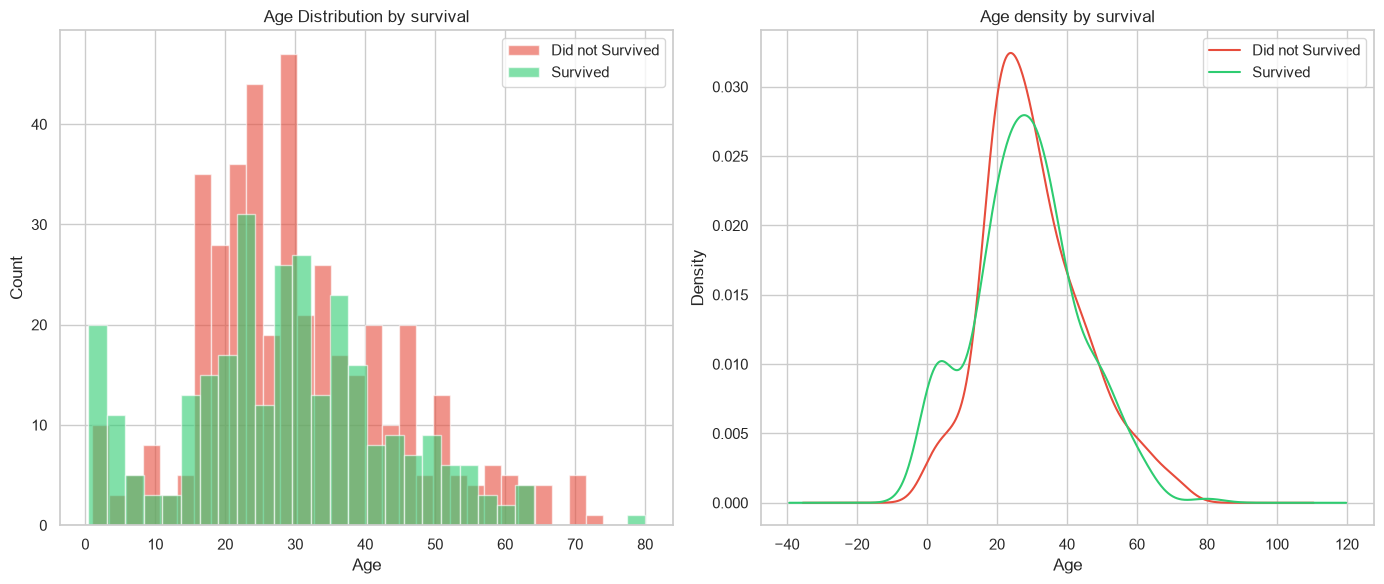

In [31]:
fig, ax = plt.subplots(1,2,figsize=(14, 6))

#Overlapping Histograms
ax[0].hist(df[df["Survived"] == 0]["Age"].dropna(), bins=30, alpha = 0.6, color = "#e74c3c", label = "Did not Survived", edgecolor="white")
ax[0].hist(df[df["Survived"] == 1]["Age"].dropna(), bins = 30, alpha= 0.6, color= "#2ecc71", label="Survived", edgecolor="white")
ax[0].set_title("Age Distribution by survival")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Count")
ax[0].legend()

#Kde plot
df[df["Survived"] == 0]["Age"].dropna().plot.kde(ax=ax[1], color = "#e74c3c", label = "Did not Survived")
df[df["Survived"] == 1]["Age"].dropna().plot.kde(ax=ax[1], color = "#2ecc71", label = "Survived")
ax[1].set_title("Age density by survival")
ax[1].set_xlabel("Age")
ax[1].legend()

plt.tight_layout()
plt.show()

C:\Users\Mridul\AppData\Local\Temp\ipykernel_13276\1616282500.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y="Fare", data=df, palette=["#e74c3c", "#2ecc71"], ax = ax)
C:\Users\Mridul\AppData\Local\Temp\ipykernel_13276\1616282500.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Did not Survived", "Survived"])


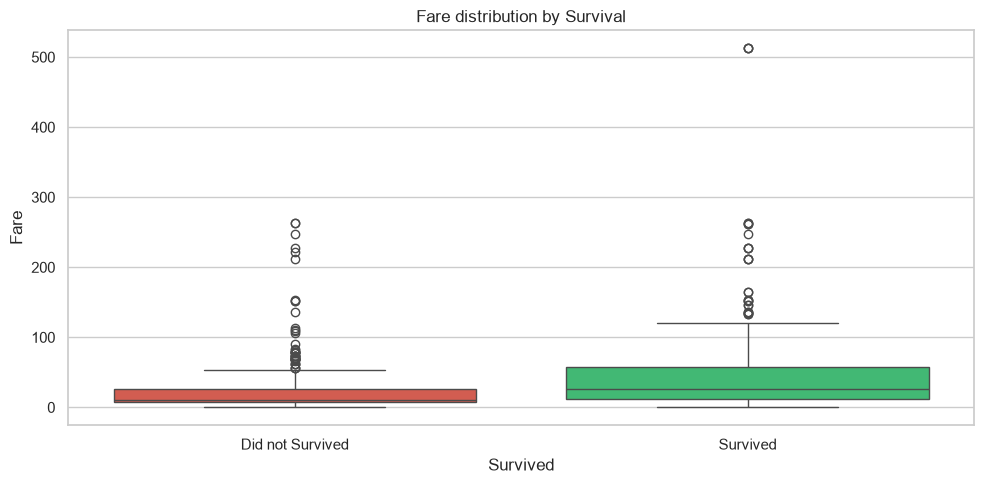

Average Fare - Survived: $48.40
Average Fare - Did Not Survived: $22.12


In [7]:
#Fare Distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x="Survived", y="Fare", data=df, palette=["#e74c3c", "#2ecc71"], ax = ax)
ax.set_xticklabels(["Did not Survived", "Survived"])
ax.set_title("Fare distribution by Survival")
plt.tight_layout()
plt.show()

print(f"Average Fare - Survived: ${df[df["Survived"] == 1]["Fare"].mean():.2f}")
print(f"Average Fare - Did Not Survived: ${df[df["Survived"] == 0]["Fare"].mean():.2f}")

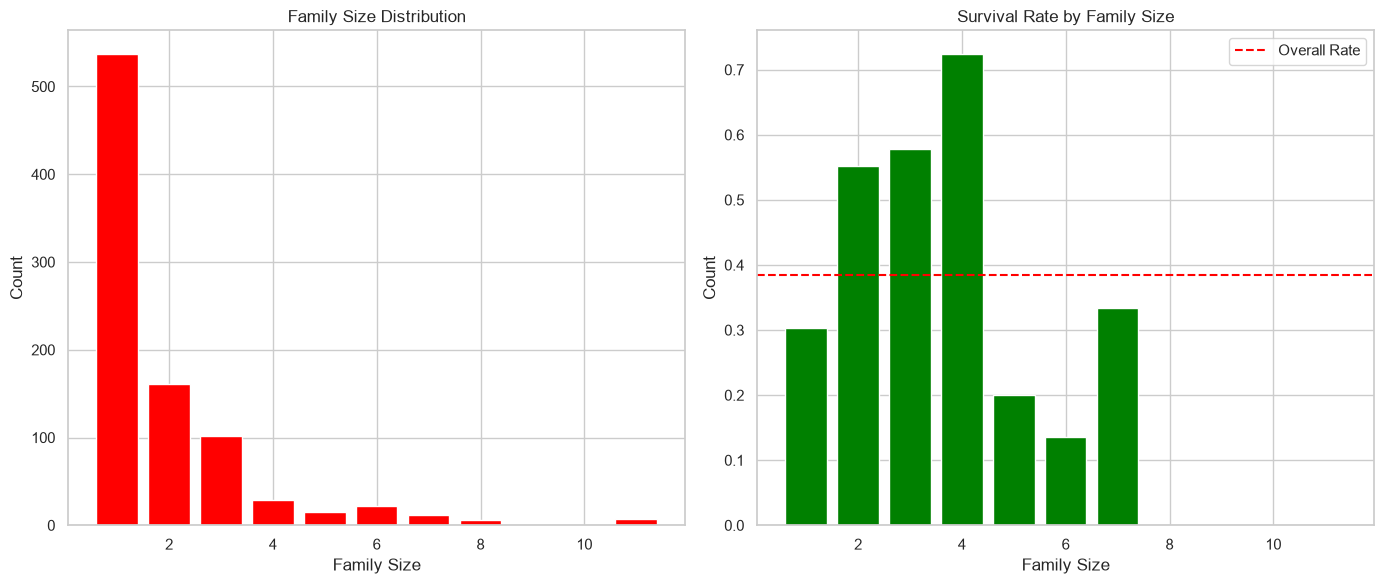

In [20]:
#Family Size Analysis
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
fig, ax = plt.subplots(1,2,figsize = (14,6))

family_counts = df["FamilySize"].value_counts().sort_index()
ax[0].bar(family_counts.index, family_counts.values, color = "red", edgecolor = "white")
ax[0].set_title("Family Size Distribution")
ax[0].set_xlabel("Family Size")
ax[0].set_ylabel("Count")


survival_by_family = df.groupby("FamilySize")["Survived"].mean()
ax[1].bar(survival_by_family.index, survival_by_family.values, color = "green", edgecolor="white")
ax[1].set_title("Survival Rate by Family Size")
ax[1].set_xlabel("Family Size")
ax[1].set_ylabel("Count")
ax[1].axhline(y=df["Survived"].mean(), color="red", linestyle="--", label="Overall Rate")
ax[1].legend()
plt.tight_layout()
plt.show()

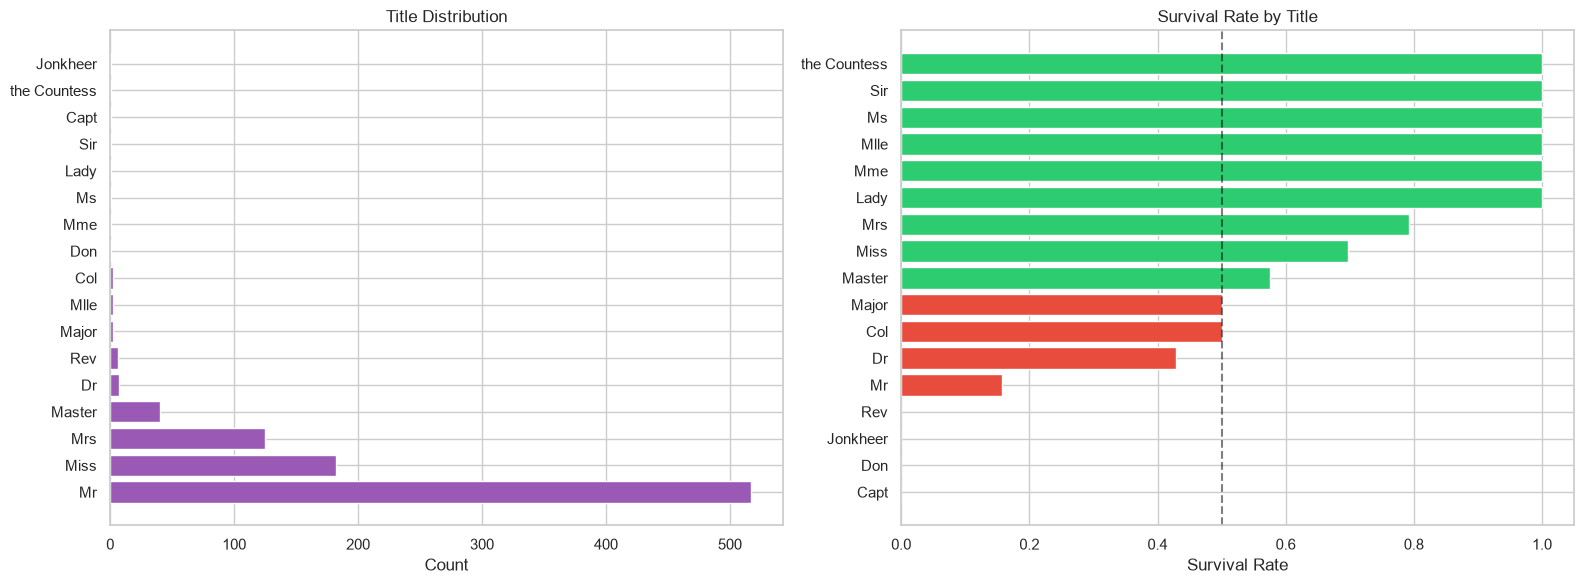

In [18]:
#Extract title from name
df["Title"] = df["Name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())

fig, ax = plt.subplots(1, 2, figsize = (16,6))

#Title Dsitribution
title_counts = df["Title"].value_counts()
ax[0].barh(title_counts.index, title_counts.values, color = "#9b59b6")
ax[0].set_title("Title Distribution")
ax[0].set_xlabel("Count")

#Survival Rate by Title
survival_by_title = df.groupby("Title")["Survived"].mean().sort_values()
colors = ["#2ecc71" if v > 0.5 else "#e74c3c" for v in survival_by_title.values]
ax[1].barh(survival_by_title.index, survival_by_title.values, color = colors)
ax[1].set_title("Survival Rate by Title")
ax[1].set_xlabel("Survival Rate")
ax[1].axvline(x=0.5, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

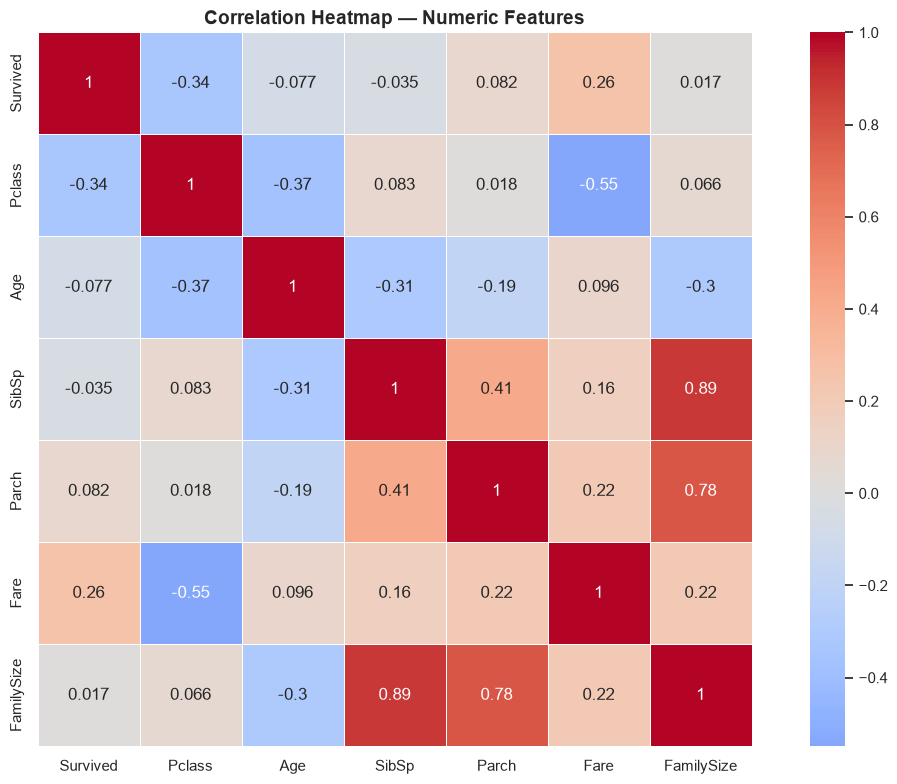

In [21]:
#Correlation Heatmap
numerical_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
corr_matrix = df[numerical_cols].corr()

fig, ax= plt.subplots(figsize = (12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap = "coolwarm",
    center = 0,
    square = True,
    linewidths = 0.5,
    ax = ax
)
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()